In [2]:
import jax
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import jaxlib
import seaborn as sns
from ssms.basic_simulators import simulator
import pytensor
import pymc
import arviz as az
import bambi as bmb
import hssm
import os
import sys
import time
import ipywidgets
import blackjax
import hddm_wfpt


# Setting float precision in pytensor
pytensor.config.floatX = "float32"

#from jax.config import config
jax.config.update("jax_enable_x64", False)


hssm.set_floatX("float32")

Setting PyTensor floatX type to float32.
Setting "jax_enable_x64" to False. If this is not intended, please set `jax` to False.


In [3]:
DDM_SP2_filtered = pd.read_csv('DDM_SP2_filtered.csv')
DDM_SP2_filtered = DDM_SP2_filtered.dropna()

In [31]:
#Drift Boundary Vary

ddm_model_V11_filtered = hssm.HSSM(
    data=DDM_SP2_filtered,
    model="ddm",
    include=[
        {
            "name": "a",
            "prior": {
                "Intercept": {"name": "Normal", "mu": 3.2, "sigma": 0.1},
                "condition": {"name": "Normal", "mu": 0.0, "sigma": 0.05},
            },
            "formula": "a ~ 1 + condition",
            "link": "identity",
        },
    ]
)

Model initialized successfully.


In [49]:
posterior_ddm_model_V11_filtered = ddm_model_V11.sample(
    sampler="nuts_blackjax",
    cores=4,              # Utilize 4 CPU cores for parallel chain execution
    chains=3,             # Run 4 independent chains for better convergence diagnostics
    draws=3000,           # Collect 3000 post-tuning samples per chain
    tune=1000,            # Use 1000 iterations for warm-up (adjust if necessary)
    #target_accept=0.90,   # Adjust target acceptance rate for more challenging posteriors
    idata_kwargs=dict(log_likelihood=True)
)

Using default initvals. 



The model has already been sampled. Overwriting the previous inference object. Any previous reference to the inference object will still point to the old object.


c:\Users\ellal\anaconda3\envs\tear\lib\site-packages\jax\_src\numpy\array_methods.py:118: UserWarning: Explicitly requested dtype float64 requested in astype is not available, and will be truncated to dtype float32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  return lax_numpy.astype(self, dtype, copy=copy, device=device)
c:\Users\ellal\anaconda3\envs\tear\lib\site-packages\jax\_src\numpy\array_methods.py:118: UserWarning: Explicitly requested dtype float64 requested in astype is not available, and will be truncated to dtype float32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  return lax_numpy.astype(self, dtype, copy=copy, device=device)
c:\Users\ellal\anaconda3\envs\tear\lib\site-packages\jax\_src\numpy\array_methods.py

Running window adaptation


c:\Users\ellal\anaconda3\envs\tear\lib\site-packages\jax\_src\numpy\array_methods.py:118: UserWarning: Explicitly requested dtype float64 requested in astype is not available, and will be truncated to dtype float32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  return lax_numpy.astype(self, dtype, copy=copy, device=device)
c:\Users\ellal\anaconda3\envs\tear\lib\site-packages\jax\_src\numpy\array_methods.py:118: UserWarning: Explicitly requested dtype float64 requested in astype is not available, and will be truncated to dtype float32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  return lax_numpy.astype(self, dtype, copy=copy, device=device)
c:\Users\ellal\anaconda3\envs\tear\lib\site-packages\jax\_src\numpy\array_methods.py

We recommend running at least 4 chains for robust computation of convergence diagnostics
c:\Users\ellal\anaconda3\envs\tear\lib\site-packages\pymc\pytensorf.py:958: FutureWarning: compile_pymc was renamed to compile. Old name will be removed in a future release of PyMC
  warnings.warn(
100%|██████████| 9000/9000 [02:20<00:00, 64.01it/s] 


In [39]:
varied = az.summary(posterior_ddm_model_V11_filtered)

varied.to_csv("posterior_ddm_model_V1_filtered.csv")

In [37]:
az.summary(posterior_ddm_model_V11_filtered)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
t,3.518,0.001,3.516,3.519,0.000,0.0,6510.0,6324.0,1.0
a_Intercept,3.272,0.034,3.210,3.337,0.001,0.0,2480.0,2456.0,1.0
v,-1.123,0.016,-1.152,-1.091,0.000,0.0,2455.0,3271.0,1.0
a_condition,-0.018,0.026,-0.064,0.031,0.000,0.0,3527.0,3655.0,1.0
z,0.936,0.001,0.934,0.938,0.000,0.0,2630.0,3191.0,1.0


In [29]:
#Drift Rate and Boundary vary

ddm_model_V10 = hssm.HSSM(
    data=DDM_SP2_filtered,
    model="ddm",
    include=[
        {
            "name": "a",
            "prior": {
                "Intercept": {"name": "Normal", "mu": 3.2, "sigma": 0.1},
                "condition": {"name": "Normal", "mu": 0.0, "sigma": 0.05},
            },
            "formula": "a ~ 1 + condition",
            "link": "identity",
        },
        {
            "name": "v",
            "prior": {
                "Intercept": {"name": "Normal", "mu": -1.06, "sigma": 0.1},
                "condition": {"name": "Normal", "mu": 0.0, "sigma": 0.05},
            },
            "formula": "v ~ 1 + condition",
            "link": "identity",
        },
    ]
)

Model initialized successfully.


In [46]:
posterior_ddm_model_V2 = ddm_model_V10.sample(
    sampler="nuts_blackjax",
    cores=4,              # Utilize 4 CPU cores for parallel chain execution
    chains=3,             # Run 4 independent chains for better convergence diagnostics
    draws=3000,           # Collect 3000 post-tuning samples per chain
    tune=1000,            # Use 1000 iterations for warm-up (adjust if necessary)
    #target_accept=0.90,   # Adjust target acceptance rate for more challenging posteriors
    idata_kwargs=dict(log_likelihood=True)
)

Using default initvals. 



c:\Users\ellal\anaconda3\envs\tear\lib\site-packages\jax\_src\numpy\array_methods.py:118: UserWarning: Explicitly requested dtype float64 requested in astype is not available, and will be truncated to dtype float32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  return lax_numpy.astype(self, dtype, copy=copy, device=device)
c:\Users\ellal\anaconda3\envs\tear\lib\site-packages\jax\_src\numpy\array_methods.py:118: UserWarning: Explicitly requested dtype float64 requested in astype is not available, and will be truncated to dtype float32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  return lax_numpy.astype(self, dtype, copy=copy, device=device)
c:\Users\ellal\anaconda3\envs\tear\lib\site-packages\jax\_src\numpy\array_methods.py

Running window adaptation


c:\Users\ellal\anaconda3\envs\tear\lib\site-packages\jax\_src\numpy\array_methods.py:118: UserWarning: Explicitly requested dtype float64 requested in astype is not available, and will be truncated to dtype float32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  return lax_numpy.astype(self, dtype, copy=copy, device=device)
c:\Users\ellal\anaconda3\envs\tear\lib\site-packages\jax\_src\numpy\array_methods.py:118: UserWarning: Explicitly requested dtype float64 requested in astype is not available, and will be truncated to dtype float32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  return lax_numpy.astype(self, dtype, copy=copy, device=device)
c:\Users\ellal\anaconda3\envs\tear\lib\site-packages\jax\_src\numpy\array_methods.py

We recommend running at least 4 chains for robust computation of convergence diagnostics
c:\Users\ellal\anaconda3\envs\tear\lib\site-packages\pymc\pytensorf.py:958: FutureWarning: compile_pymc was renamed to compile. Old name will be removed in a future release of PyMC
  warnings.warn(
100%|██████████| 9000/9000 [00:53<00:00, 169.71it/s]


In [47]:
varied = az.summary(posterior_ddm_model_V2)

varied.to_csv("posterior_ddm_model_V2_filtered.csv")

In [48]:
az.summary(posterior_ddm_model_V2)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
v_Intercept,-1.156,0.018,-1.191,-1.123,0.000,0.0,3176.0,3812.0,1.0
t,3.518,0.001,3.516,3.519,0.000,0.0,7390.0,6807.0,1.0
v_condition,0.071,0.018,0.036,0.104,0.000,0.0,3513.0,4229.0,1.0
a_Intercept,3.301,0.034,3.237,3.366,0.001,0.0,3151.0,3968.0,1.0
a_condition,-0.081,0.030,-0.139,-0.027,0.001,0.0,3472.0,4346.0,1.0
z,0.936,0.001,0.934,0.938,0.000,0.0,3001.0,3926.0,1.0


In [4]:
ddm_model_varied_filtered = hssm.HSSM(
    data=DDM_SP2_filtered,
    model="ddm",
    include=[
        {
            "name": "a",
            "formula": "a ~ 1 + condition",
            "link": "identity",
            "prior": {
                "Intercept": {"name": "Normal", "mu": 3.2, "sigma": 0.2},
                "condition": {"name": "Normal", "mu": 0.0, "sigma": 0.2}
            }
        },
        {
            "name": "v",
            "formula": "v ~ 1 + condition",
            "link": "identity",
            "prior": {
                "Intercept": {"name": "Normal", "mu": -1.06, "sigma": 0.2},
                "condition": {"name": "Normal", "mu": 0.0, "sigma": 0.2}
            }
        },
        {
            "name": "z",
            "formula": "z ~ 1 + condition",
            "link": "identity",
            "prior": {
                "Intercept": {"name": "Normal", "mu": 0.935, "sigma": 0.02},
                "condition": {"name": "Normal", "mu": 0.0, "sigma": 0.02}
            }
        }
        # 🛑 No formula for 't', so it will be estimated as a global constant
    ]
)

Model initialized successfully.


In [5]:
posterior_ddm_model_varied_filtered = ddm_model_varied_filtered.sample(
    sampler="nuts_blackjax",
    cores=4,              # Utilize 4 CPU cores for parallel chain execution
    chains=4,             # Run 4 independent chains for better convergence diagnostics
    draws=3000,           # Collect 3000 post-tuning samples per chain
    tune=1000,            # Use 1000 iterations for warm-up (adjust if necessary)
    #target_accept=0.90,   # Adjust target acceptance rate for more challenging posteriors
    idata_kwargs=dict(log_likelihood=True)
)

Using default initvals. 



c:\Users\ellal\anaconda3\envs\tear\lib\site-packages\jax\_src\numpy\array_methods.py:118: UserWarning: Explicitly requested dtype float64 requested in astype is not available, and will be truncated to dtype float32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  return lax_numpy.astype(self, dtype, copy=copy, device=device)
c:\Users\ellal\anaconda3\envs\tear\lib\site-packages\jax\_src\numpy\array_methods.py:118: UserWarning: Explicitly requested dtype float64 requested in astype is not available, and will be truncated to dtype float32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  return lax_numpy.astype(self, dtype, copy=copy, device=device)
c:\Users\ellal\anaconda3\envs\tear\lib\site-packages\jax\_src\numpy\array_methods.py

Running window adaptation


c:\Users\ellal\anaconda3\envs\tear\lib\site-packages\jax\_src\numpy\array_methods.py:118: UserWarning: Explicitly requested dtype float64 requested in astype is not available, and will be truncated to dtype float32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  return lax_numpy.astype(self, dtype, copy=copy, device=device)
c:\Users\ellal\anaconda3\envs\tear\lib\site-packages\jax\_src\numpy\array_methods.py:118: UserWarning: Explicitly requested dtype float64 requested in astype is not available, and will be truncated to dtype float32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  return lax_numpy.astype(self, dtype, copy=copy, device=device)
c:\Users\ellal\anaconda3\envs\tear\lib\site-packages\jax\_src\numpy\array_methods.py

c:\Users\ellal\anaconda3\envs\tear\lib\site-packages\pymc\pytensorf.py:958: FutureWarning: compile_pymc was renamed to compile. Old name will be removed in a future release of PyMC
  warnings.warn(
100%|██████████| 12000/12000 [01:45<00:00, 113.69it/s]


In [7]:
varied = az.summary(posterior_ddm_model_varied_filtered)

az.to_netcdf(posterior_ddm_model_varied_filtered, "posterior_ddm_model_V3_filtered.nc")
varied.to_csv("posterior_ddm_model_V3_filtered.csv")

c:\Users\ellal\anaconda3\envs\tear\lib\site-packages\h5py\__init__.py:36: UserWarning: h5py is running against HDF5 1.14.6 when it was built against 1.14.5, this may cause problems
  _warn(("h5py is running against HDF5 {0} when it was built against {1}, "


In [9]:
varied = pd.read_csv("posterior_ddm_model_V3_filtered.csv")
idata = az.from_netcdf("posterior_ddm_model_V3_filtered.nc")

In [8]:
az.summary(posterior_ddm_model_varied_filtered)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
v_condition,0.163,0.031,0.105,0.221,0.001,0.000,3546.0,4478.0,1.0
a_Intercept,3.408,0.045,3.324,3.495,0.001,0.001,3335.0,4250.0,1.0
z_condition,-0.006,0.002,-0.009,-0.002,0.000,0.000,4576.0,5856.0,1.0
a_condition,-0.271,0.061,-0.386,-0.158,0.001,0.001,3504.0,4580.0,1.0
t,3.518,0.001,3.516,3.519,0.000,0.000,11509.0,9876.0,1.0
v_Intercept,-1.208,0.023,-1.252,-1.165,0.000,0.000,3500.0,3946.0,1.0
z_Intercept,0.939,0.001,0.936,0.942,0.000,0.000,4603.0,6098.0,1.0


In [10]:
# Extract posterior samples for `a` for each condition
# These are usually labeled like 'a_condition[1]', 'a_condition[2]', etc. depending on your coding
idata = posterior_ddm_model_varied_filtered

# Get posterior samples for the relevant contrasts
a_intercept = idata.posterior["a_Intercept"]  # shape: (chain, draw)
a_condition = idata.posterior["a_condition"]  # difference from intercept (e.g., fatigue effect)

# Calculate difference: fatigue - control
a_fatigue = a_intercept + a_condition
a_diff = a_condition.values.flatten()

In [11]:
# Define ROPE based on your RTs
rope_lower, rope_upper = -0.06, 0.06 #-0.03, 0.03
within_rope = ((a_diff > rope_lower) & (a_diff < rope_upper)).mean()
outside_rope = 1 - within_rope

print(f"{within_rope*100:.1f}% of the posterior difference is within the ROPE.")
print(f"{outside_rope * 100:.1f}% falls outside.")

0.0% of the posterior difference is within the ROPE.
100.0% falls outside.


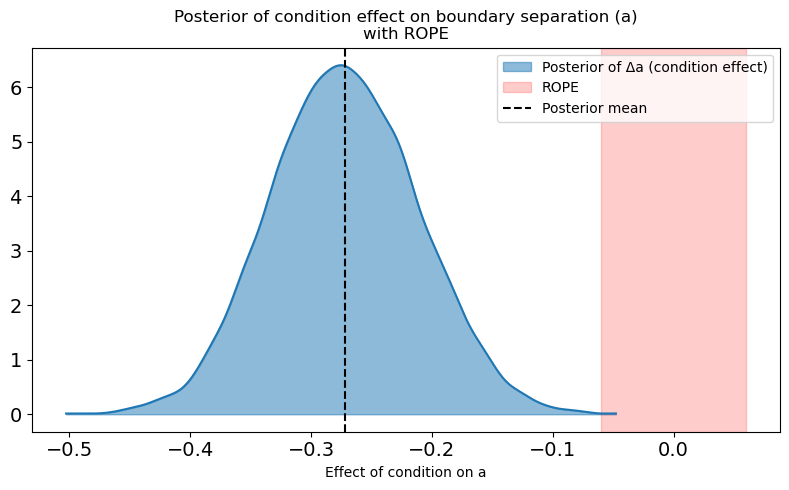

In [18]:
# Extract posterior difference (condition effect on boundary separation)
a_condition = idata.posterior["a_condition"].values.flatten()

# Set ROPE bounds
rope_lower, rope_upper = -0.06, 0.06

# Plot
plt.figure(figsize=(8, 5))
az.plot_kde(a_condition, label="Posterior of Δa (condition effect)", fill_kwargs={"alpha": 0.5})

# Add ROPE region
plt.axvspan(rope_lower, rope_upper, color="red", alpha=0.2, label="ROPE")

# Add mean line
plt.axvline(np.mean(a_condition), color="black", linestyle="--", label="Posterior mean")

# Styling
plt.xlabel("Effect of condition on a")
plt.title("Posterior of condition effect on boundary separation (a)\nwith ROPE")
plt.legend()
plt.tight_layout()
plt.show()

In [22]:
# Define ROPE
rope_lower, rope_upper = -0.06, 0.06

# Compute proportions
within_rope = ((v_condition > rope_lower) & (v_condition < rope_upper)).mean()
outside_rope = 1 - within_rope

# Print results
print(f"{within_rope * 100:.1f}% of the posterior is within the ROPE.")
print(f"{outside_rope * 100:.1f}% of the posterior is outside the ROPE.")

0.0% of the posterior is within the ROPE.
100.0% of the posterior is outside the ROPE.


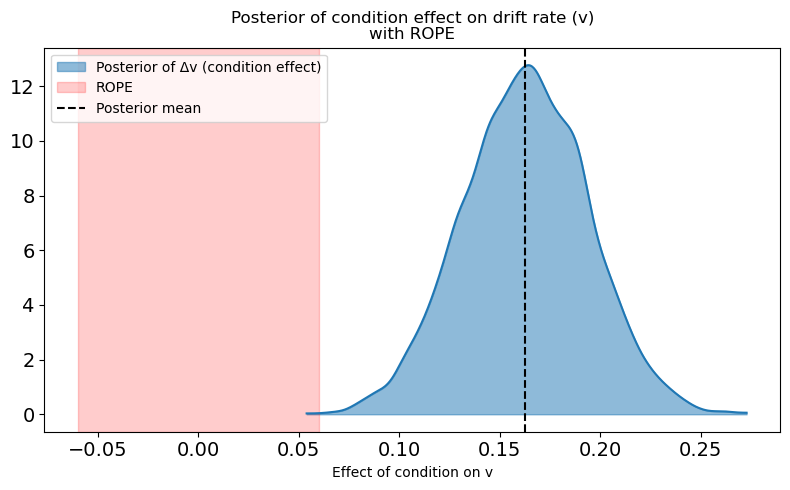

In [20]:
# Extract posterior difference (condition effect on drift rate)
v_condition = idata.posterior["v_condition"].values.flatten()

# Set ROPE bounds (you can adjust this based on what constitutes a negligible effect in your task)
rope_lower, rope_upper = -0.06, 0.06

# Plot
plt.figure(figsize=(8, 5))
az.plot_kde(v_condition, label="Posterior of Δv (condition effect)", fill_kwargs={"alpha": 0.5})

# Add ROPE region
plt.axvspan(rope_lower, rope_upper, color="red", alpha=0.2, label="ROPE")

# Add mean line
plt.axvline(np.mean(v_condition), color="black", linestyle="--", label="Posterior mean")

# Styling
plt.xlabel("Effect of condition on v")
plt.title("Posterior of condition effect on drift rate (v)\nwith ROPE")
plt.legend()
plt.tight_layout()
plt.show()

In [12]:
#starting point
# Extract posterior samples for `z` (starting point) for each condition
idata = posterior_ddm_model_varied_filtered

# Get posterior samples for the relevant contrasts
z_intercept = idata.posterior["z_Intercept"]   # baseline (control condition)
z_condition = idata.posterior["z_condition"]   # condition effect (e.g., fatigue effect)

# Calculate condition-specific posteriors
z_fatigue = z_intercept + z_condition          # starting point under fatigue condition
z_diff = z_condition.values.flatten()          # difference (fatigue - control)


In [14]:
# Define ROPE
rope_lower, rope_upper = -0.06, 0.06

# Compute proportions
within_rope = ((z_condition > rope_lower) & (z_condition < rope_upper)).mean()
outside_rope = 1 - within_rope

# Print results
print(f"{within_rope * 100:.1f}% of the posterior is within the ROPE.")
print(f"{outside_rope * 100:.1f}% of the posterior is outside the ROPE.")

100.0% of the posterior is within the ROPE.
0.0% of the posterior is outside the ROPE.


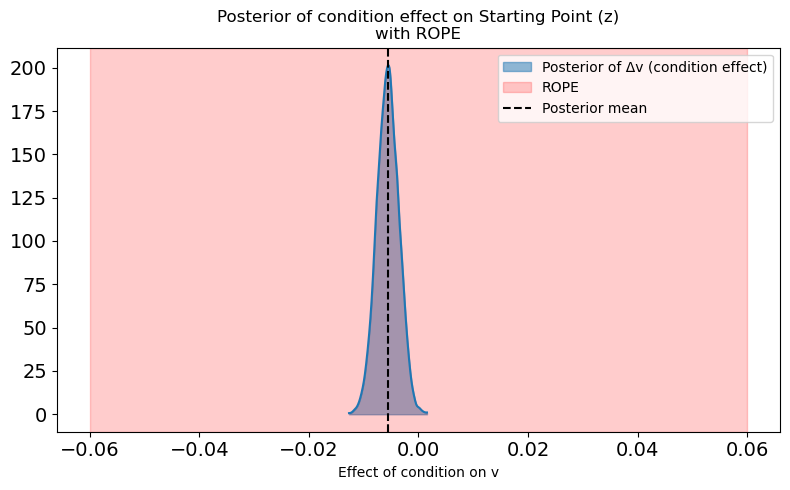

In [16]:
# Extract posterior difference (condition effect on drift rate)
z_condition = idata.posterior["z_condition"].values.flatten()

# Set ROPE bounds (you can adjust this based on what constitutes a negligible effect in your task)
rope_lower, rope_upper = -0.06, 0.06

# Plot
plt.figure(figsize=(8, 5))
az.plot_kde(z_condition, label="Posterior of Δv (condition effect)", fill_kwargs={"alpha": 0.5})

# Add ROPE region
plt.axvspan(rope_lower, rope_upper, color="red", alpha=0.2, label="ROPE")

# Add mean line
plt.axvline(np.mean(z_condition), color="black", linestyle="--", label="Posterior mean")

# Styling
plt.xlabel("Effect of condition on v")
plt.title("Posterior of condition effect on Starting Point (z)\nwith ROPE")
plt.legend()
plt.tight_layout()
plt.show()

In [43]:
ddm_model_all = hssm.HSSM(
    data=DDM_SP2_filtered,
    model="ddm",
    include=[
        {
            "name": "a",
            "formula": "a ~ 1 + condition",
            "link": "identity",
            "prior": {
                "Intercept": {"name": "Normal", "mu": 3.2, "sigma": 0.2},
                "condition": {"name": "Normal", "mu": 0.0, "sigma": 0.2}
            }
        },
        {
            "name": "v",
            "formula": "v ~ 1 + condition",
            "link": "identity",
            "prior": {
                "Intercept": {"name": "Normal", "mu": -1.06, "sigma": 0.2},
                "condition": {"name": "Normal", "mu": 0.0, "sigma": 0.2}
            }
        },
        {
            "name": "t",
            "formula": "t ~ 1 + condition",
            "link": "identity",
            "prior": {
                "Intercept": {"name": "Normal", "mu": 3.52, "sigma": 0.1},
                "condition": {"name": "Normal", "mu": 0.0, "sigma": 0.05}
            }
        },
        {
            "name": "z",
            "formula": "z ~ 1 + condition",
            "link": "identity",
            "prior": {
                "Intercept": {"name": "Normal", "mu": 0.935, "sigma": 0.02},
                "condition": {"name": "Normal", "mu": 0.0, "sigma": 0.02}
            }
        }
    ]
)

Model initialized successfully.


In [44]:
posterior_ddm_model_all = ddm_model_all.sample(
    sampler="nuts_blackjax",
    cores=4,              # Utilize 4 CPU cores for parallel chain execution
    chains=4,             # Run 4 independent chains for better convergence diagnostics
    draws=3000,           # Collect 3000 post-tuning samples per chain
    tune=1000,            # Use 1000 iterations for warm-up (adjust if necessary)
    #target_accept=0.90,   # Adjust target acceptance rate for more challenging posteriors
    idata_kwargs=dict(log_likelihood=True)
)

Using default initvals. 



c:\Users\ellal\anaconda3\envs\tear\lib\site-packages\jax\_src\numpy\array_methods.py:118: UserWarning: Explicitly requested dtype float64 requested in astype is not available, and will be truncated to dtype float32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  return lax_numpy.astype(self, dtype, copy=copy, device=device)
c:\Users\ellal\anaconda3\envs\tear\lib\site-packages\jax\_src\numpy\array_methods.py:118: UserWarning: Explicitly requested dtype float64 requested in astype is not available, and will be truncated to dtype float32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  return lax_numpy.astype(self, dtype, copy=copy, device=device)
c:\Users\ellal\anaconda3\envs\tear\lib\site-packages\jax\_src\numpy\array_methods.py

Running window adaptation


c:\Users\ellal\anaconda3\envs\tear\lib\site-packages\jax\_src\numpy\array_methods.py:118: UserWarning: Explicitly requested dtype float64 requested in astype is not available, and will be truncated to dtype float32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  return lax_numpy.astype(self, dtype, copy=copy, device=device)
c:\Users\ellal\anaconda3\envs\tear\lib\site-packages\jax\_src\numpy\array_methods.py:118: UserWarning: Explicitly requested dtype float64 requested in astype is not available, and will be truncated to dtype float32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  return lax_numpy.astype(self, dtype, copy=copy, device=device)
c:\Users\ellal\anaconda3\envs\tear\lib\site-packages\jax\_src\numpy\array_methods.py

The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details
c:\Users\ellal\anaconda3\envs\tear\lib\site-packages\pymc\pytensorf.py:958: FutureWarning: compile_pymc was renamed to compile. Old name will be removed in a future release of PyMC
  warnings.warn(
100%|██████████| 12000/12000 [01:14<00:00, 160.78it/s]


In [45]:
Vall = az.summary(posterior_ddm_model_all)

Vall.to_csv("posterior_ddm_model_V4_filtered.csv")

az.summary(posterior_ddm_model_all)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
v_Intercept,-0.502,1.198,-1.243,1.622,0.598,0.458,7.0,28.0,1.53
t_condition,0.020,0.026,0.001,0.070,0.013,0.010,7.0,29.0,1.53
v_condition,-0.551,1.185,-2.653,0.203,0.592,0.453,7.0,28.0,1.53
a_Intercept,3.379,0.090,3.167,3.536,0.002,0.001,3389.0,31.0,1.18
a_condition,-0.234,0.096,-0.415,-0.038,0.002,0.006,3540.0,35.0,1.12
z_condition,0.013,0.027,-0.007,0.065,0.013,0.010,7.0,29.0,1.53
z_Intercept,0.921,0.028,0.869,0.941,0.014,0.011,7.0,28.0,1.53
t_Intercept,3.500,0.026,3.450,3.518,0.013,0.010,7.0,29.0,1.53


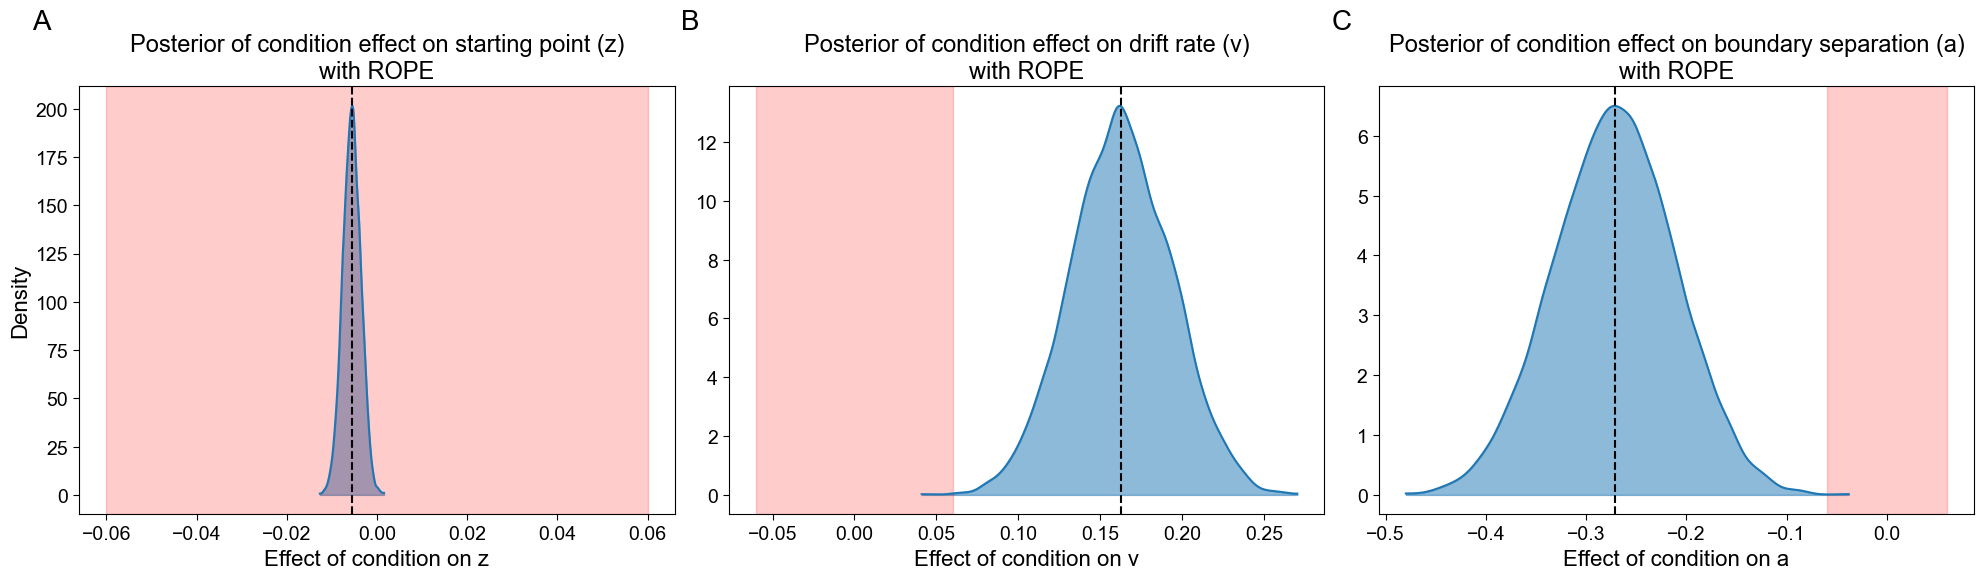

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import arviz as az
import pandas as pd

# Load
idata = az.from_netcdf("posterior_ddm_model_V3_filtered.nc")

# Posterior vectors
z_condition = idata.posterior["q_condition"].values.flatten()
v_condition = idata.posterior["v_condition"].values.flatten()
a_condition = idata.posterior["z_condition"].values.flatten()

posteriors = [z_condition, v_condition, a_condition]

titles = [
    "Posterior of condition effect on boundary separation (z)\nwith ROPE",
    "Posterior of condition effect on drift rate (v)\nwith ROPE",
    "Posterior of condition effect on starting point (a)\nwith ROPE"
]

xlabels = [
    "Effect of condition on a",
    "Effect of condition on v",
    "Effect of condition on z"
]

panel_letters = ["A", "B", "C"]

rope_lower, rope_upper = -0.06, 0.06

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for ax, posterior, title, xlabel, letter in zip(
        axes, posteriors, titles, xlabels, panel_letters):

    # KDE
    az.plot_kde(posterior, ax=ax, fill_kwargs={"alpha": 0.5})

    # ROPE
    ax.axvspan(rope_lower, rope_upper, color="red", alpha=0.2)

    # Posterior mean
    ax.axvline(np.mean(posterior), color="black", linestyle="--")

    # Axis label + title with larger font sizes
    ax.set_xlabel(xlabel, fontsize=16)
    ax.set_title(title, fontsize=17)

    # Tick labels larger
    ax.tick_params(labelsize=14)

    # Panel letter in top-left, above the axes (not bold)
    ax.annotate(letter,
                xy=(-0.08, 1.12),
                xycoords='axes fraction',
                ha='left', va='bottom',
                fontsize=20)

axes[0].set_ylabel("Density", fontsize=16)

plt.tight_layout()
plt.show()




In [19]:
plt.savefig("posterior_three_panel.pdf", dpi=300, bbox_inches="tight")


<Figure size 640x480 with 0 Axes>